In [2]:
import pandas as pd
import pathlib
import sys
import matplotlib.pyplot as plt
import numpy as np
import gensim
from collections import defaultdict
from gensim import corpora
import re
from gensim.models import LdaModel
import spacy
from spacy.tokenizer import Tokenizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import LatentDirichletAllocation
from pathlib import Path
import sys
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

In [3]:
nlp = spacy.load("fr_core_news_lg")
nlp_trf = spacy.load("fr_dep_news_trf")

In [4]:
dossier_path = Path("corpus_goncourt")

donnees = []

# On boucle sur tous les fichiers .txt du dossier
for fichier in dossier_path.glob("*.txt"):
    with open(fichier, "r", encoding="utf-8") as f:
        contenu = f.read()
        
        # On détermine le label selon le nom du fichier
    donnees.append({
            "nom_fichier": fichier.name,
            "texte_brut": contenu,
        })
      
         

# Création du tableau de bord (DataFrame)
df = pd.DataFrame(donnees)
print(f"{len(df)} textes chargés avec succès.")

df

10 textes chargés avec succès.


,nom_fichier,texte_brut
0,1869_madame_gervaisais_travail.txt,"— Quarante scudi ?\n— Oui, signora.\n— Cela fa..."
1,1884_cherie_travail.txt,"petites amies à peu près de son âge, des place..."
2,1861_sœur_philomène_travail.txt,"La salle est haute et vaste. Elle est longue, ..."
3,1879_frères_zemganno_travail.txt,"En pleine campagne, au pied d’un poteau d’octr..."
4,1877_la_fille_elisa_travail.txt,"La femme, la prostituée condamnée à mort, étai..."
5,1865_germinie_lacerteux_travail.txt,"— Sauvée ! vous voilà donc sauvée, mademoisell..."
6,1867_manette_salomon_travail.txt,On était au commencement de novembre. La derni...
7,1860_Charles Demailly_travail.txt,– Un article ?… Tu me demandes s’ y a un artic...
8,1882_la_faustin_travail.txt,"faisait nuit sous un ciel étoilé, au-dessus d'..."
9,1864_renée_mauperin_travail.txt,"— Vous n’aimez pas le monde, mademoiselle ?\n—..."


In [9]:
def segmenter_texte(text, taille=300):
    mots = text.split()
    segments = []
    for i in range(0, len(mots), taille):
        segment = " ".join(mots[i:i+taille])
        if len(segment.split()) >= 100: 
            segments.append(segment)
    return segments

In [10]:
lignes = []

for _, row in df.iterrows():
    titre = row["nom_fichier"]
    texte = row["texte_brut"]
    segments = segmenter_texte(texte)
    
    for j, seg in enumerate(segments):
        lignes.append({
            "titre": titre,
            "segment_id": j,
            "texte_segment": seg
        })

df_segments = pd.DataFrame(lignes)

In [11]:
df_segments

,titre,segment_id,texte_segment
0,1869_madame_gervaisais_travail.txt,0,"— Quarante scudi ? — Oui, signora. — Cela fait..."
1,1869_madame_gervaisais_travail.txt,1,"suivent… — Oui, signora… Nous, nous nous retir..."
2,1869_madame_gervaisais_travail.txt,2,et trempant la plume dans la boue d’un encrier...
3,1869_madame_gervaisais_travail.txt,3,"sa vie, Jules demandait à Edmond de lui en fai..."
4,1869_madame_gervaisais_travail.txt,4,place des touristes consciencieux lisaient le ...
...,...,...,...
2275,1864_renée_mauperin_travail.txt,219,"à son aise, dans son coin, la tête contre le m..."
2276,1864_renée_mauperin_travail.txt,220,disaient bientôt plus rien ; ils restaient mue...
2277,1864_renée_mauperin_travail.txt,221,trempaient dans la lumière le bord de leurs fe...
2278,1864_renée_mauperin_travail.txt,222,"cinq sous, des joujoux gagnés à des loteries, ..."


In [13]:
def nettoyer_texte(texte):
    doc = nlp(texte)
    tokens = []
    
    for token in doc:
        if (
            not token.is_stop
            and not token.is_punct
            and not token.like_num
            and not token.is_space
            and token.pos_ in {"NOUN", "ADJ"}
            and len(token.lemma_) > 2
        ):
            tokens.append(token.lemma_.lower())
    
    return " ".join(tokens)

In [14]:
df_segments["texte_nettoye"] = df_segments["texte_segment"].apply(nettoyer_texte)

df_segments[["texte_segment", "texte_nettoye"]].head()

,texte_segment,texte_nettoye
0,"— Quarante scudi ? — Oui, signora. — Cela fait...",scudi monnaie cent franc cent franc romaine ap...
1,"suivent… — Oui, signora… Nous, nous nous retir...",petit chambre fond besoin mère romaine vieux f...
2,et trempant la plume dans la boue d’un encrier...,plume boue encrier nom reçu étranger carte mon...
3,"sa vie, Jules demandait à Edmond de lui en fai...",vie lecture haut mémoire idée manie matin soir...
4,place des touristes consciencieux lisaient le ...,place touriste consciencieux guide assiette so...


In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_df=0.8,
    min_df=5
)

X = vectorizer.fit_transform(df_segments["texte_nettoye"])

In [16]:
X.shape

(2280, 4504)

/Users/morganr/Champs_lexicaux_N-A/.venv/lib/python3.12/site-packages/sklearn/decomposition/_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/Users/morganr/Champs_lexicaux_N-A/.venv/lib/python3.12/site-packages/sklearn/decomposition/_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/Users/morganr/Champs_lexicaux_N-A/.venv/lib/python3.12/site-packages/sklearn/decomposition/_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


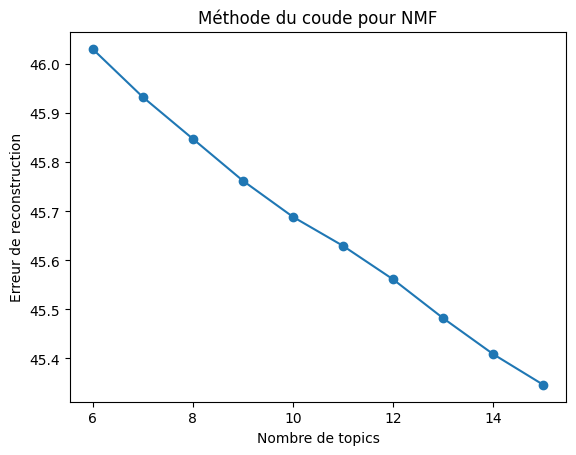

In [19]:
from sklearn.decomposition import NMF
import matplotlib.pyplot as plt

ks = range(6, 16)
errors = []

for k in ks:
    nmf = NMF(n_components=k, random_state=42)
    nmf.fit(X)
    errors.append(nmf.reconstruction_err_)

plt.plot(list(ks), errors, marker='o')
plt.xlabel("Nombre de topics")
plt.ylabel("Erreur de reconstruction")
plt.title("Méthode du coude pour NMF")
plt.show()

In [ ]:
from sklearn.decomposition import NMF

nmf = NMF(n_components=8, random_state=42)
W = nmf.fit_transform(X)
H = nmf.components_


feature_names = vectorizer.get_feature_names_out()

def afficher_topics(model, feature_names, n_top_words=10):
    for topic_idx, topic in enumerate(model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
        print(f"Topic {topic_idx+1} : {' | '.join(top_words)}")

afficher_topics(nmf, feature_names, 10)

Topic 1 : homme | franc | argent | journal | grand | art | idée | nom | ami | atelier
Topic 2 : monsieur | renée | cher | voix | vrai | monde | abbé | vou | mariage | bon
Topic 3 : petit | blanc | noir | grand | eau | ciel | ombre | arbre | lumière | soleil
Topic 4 : sœur | lit | malade | salle | interne | hôpital | médecin | main | voix | garde
Topic 5 : enfant | mère | petit | fille | père | fils | mme | bon | pauvre | jeune
Topic 6 : femme | jeune | homme | fille | amour | bal | maîtresse | mari | corps | robe
Topic 7 : frère | cirque | pied | exercice | tour | saut | directeur | aîné | clown | corps
Topic 8 : vie | pensée | cœur | âme | amour | mort | parole | jour | idée | esprit


In [20]:
nmf = NMF(n_components=10, random_state=42)
W = nmf.fit_transform(X)
H = nmf.components_


feature_names = vectorizer.get_feature_names_out()

def afficher_topics(model, feature_names, n_top_words=10):
    for topic_idx, topic in enumerate(model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
        print(f"Topic {topic_idx+1} : {' | '.join(top_words)}")

afficher_topics(nmf, feature_names, 10)

Topic 1 : heure | rue | jour | chambre | maison | bon | porte | dîner | matin | temps
Topic 2 : monsieur | renée | cher | voix | vrai | monde | abbé | vou | bon | franc
Topic 3 : blanc | petit | noir | ciel | grand | eau | arbre | ombre | soleil | lumière
Topic 4 : sœur | lit | malade | salle | interne | hôpital | médecin | voix | main | garde
Topic 5 : enfant | mère | petit | mme | fils | pauvre | père | oeil | main | bras
Topic 6 : femme | homme | amour | corps | maîtresse | oeil | main | bras | tête | théâtre
Topic 7 : frère | cirque | exercice | pied | tour | saut | directeur | aîné | clown | corps
Topic 8 : vie | pensée | cœur | amour | âme | mort | jour | parole | idée | chose
Topic 9 : fille | jeune | père | maréchal | petit | mariage | grand | renée | année | salon
Topic 10 : homme | franc | journal | art | argent | grand | talent | nom | idée | monde


In [21]:
nmf = NMF(n_components=12, random_state=42)
W = nmf.fit_transform(X)
H = nmf.components_


feature_names = vectorizer.get_feature_names_out()

def afficher_topics(model, feature_names, n_top_words=10):
    for topic_idx, topic in enumerate(model.components_):
        top_words = [feature_names[i] for i in topic.argsort()[:-n_top_words - 1:-1]]
        print(f"Topic {topic_idx+1} : {' | '.join(top_words)}")

afficher_topics(nmf, feature_names, 10)

Topic 1 : franc | rue | bon | heure | maison | jour | argent | dîner | porte | chambre
Topic 2 : monsieur | renée | voix | cher | vrai | monde | abbé | vou | maman | côté
Topic 3 : blanc | petit | noir | eau | ciel | grand | arbre | ombre | soleil | lumière
Topic 4 : sœur | lit | malade | salle | interne | hôpital | garde | médecin | voix | rideau
Topic 5 : enfant | mère | petit | fils | pauvre | oeil | main | bras | père | cœur
Topic 6 : femme | homme | amour | maîtresse | corps | mari | robe | toilette | amant | cheveu
Topic 7 : frère | cirque | exercice | pied | tour | saut | directeur | aîné | clown | tonneau
Topic 8 : mort | vie | heure | corps | pensée | oeil | tête | jour | lit | temps
Topic 9 : fille | jeune | père | maréchal | petit | mariage | renée | grand | année | salon
Topic 10 : art | atelier | tableau | artiste | peintre | toile | peinture | talent | école | grand
Topic 11 : mme | saint | église | âme | prêtre | prière | religieux | foi | religion | divin
Topic 12 : hom

/Users/morganr/Champs_lexicaux_N-A/.venv/lib/python3.12/site-packages/sklearn/decomposition/_nmf.py:1720: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
